<a href="https://colab.research.google.com/github/PhilipPersukevic/nlp-video-multimodal-extraction/blob/main/02_image_description.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🖼️ Paskaitų asistentas: paveikslėlių aprašymas

Kiekvieno paskaitos video vidurinis kadras (X) siunčiamas Gemini, kuris sugeneruoja aprašymą (y).

**Duomenų šaltinis:** MIT OpenCourseWare, 6.0001 Introduction to Computer Science and Programming in Python (Fall 2016). Licencija: CC BY-NC-SA 4.0.

In [5]:
#@title 🔗 SETUP: Install Dependencies and Configure API
!pip install -U -q google-genai

import os
from google.colab import userdata

os.environ["GEMINI_API_KEY"] = userdata.get("GOOGLE_API_KEY")
print("✅ API raktas nustatytas")

✅ API raktas nustatytas


## 🗃️ STEP 1: Kadrų įkėlimas
Įkeliame `frame-data.zip`, sukurtą pirmame notebook'e, ir jį išpakuojame.

In [6]:
#@title 🗃️ STEP 1: Upload and Extract Frames
import zipfile, shutil
from google.colab import files

uploaded = files.upload()  # pasirink frame-data.zip
frame_dir = "/content/frame-data/"
shutil.rmtree(frame_dir, ignore_errors=True)  # išvalo klaidingai išpakuotus failus
os.makedirs(frame_dir, exist_ok=True)

zip_name = next(name for name in uploaded if "frame" in name)
with zipfile.ZipFile(zip_name) as z:
    z.extractall(frame_dir)
print("✅", sorted(os.listdir(frame_dir)))

Saving audio-data.zip to audio-data (1).zip
Saving frame-data.zip to frame-data (1).zip
Saving video-data.zip to video-data (1).zip
Saving text-data.zip to text-data (1).zip
✅ ['1.jpg', '2.jpg', '3.jpg', '4.jpg', '5.jpg']


## 📝 STEP 2: Aprašymų generavimas (Gemini)
Kiekvienas kadras siunčiamas Gemini su prašymu aprašyti, kas pavaizduota. Pridėti automatiniai pakartojimai, jei serveris laikinai perkrautas (503).

Dėl laikinų Gemini serverių perkrovų (503) kodas automatiškai pereina prie atsarginių modelių, todėl skirtingi kadrai gali būti aprašyti skirtingais Gemini modeliais. Naudotas modelis matomas išvestyje.

In [9]:
#@title 📝 STEP 2: Generate Image Descriptions
import time
from google import genai
from google.genai import types

client = genai.Client()
MODELS = ["gemini-3.5-flash", "gemini-3.1-flash-lite", "gemini-flash-lite-latest", "gemini-3.8-flash"]
desc_dir = "/content/image-descriptions/"
os.makedirs(desc_dir, exist_ok=True)

PROMPT = "Aprašyk, kas pavaizduota šiame paveikslėlyje (2-3 sakiniai, lietuvių kalba)."

for filename in sorted(os.listdir(frame_dir)):
    if not filename.lower().endswith((".jpg", ".jpeg", ".png")):
        continue
    with open(os.path.join(frame_dir, filename), "rb") as f:
        image_bytes = f.read()

    description = None
    for model_name in MODELS:
        for attempt in range(1, 3):
            try:
                response = client.models.generate_content(
                    model=model_name,
                    contents=[PROMPT, types.Part.from_bytes(data=image_bytes, mime_type="image/jpeg")],
                )
                description = response.text
                break
            except Exception as e:
                print(f"{filename}, {model_name}, bandymas {attempt} nepavyko: {str(e)[:50]}")
                time.sleep(5 * attempt)
        if description:
            break

    if description:
        with open(os.path.join(desc_dir, os.path.splitext(filename)[0] + ".txt"), "w", encoding="utf-8") as f:
            f.write(description)
        print(f"✅ {filename} ({model_name})")

print("Failai:", sorted(os.listdir(desc_dir)))

1.jpg, gemini-3.5-flash, bandymas 1 nepavyko: 503 UNAVAILABLE. {'error': {'code': 503, 'message'
✅ 1.jpg (gemini-3.5-flash)
2.jpg, gemini-3.5-flash, bandymas 1 nepavyko: 503 UNAVAILABLE. {'error': {'code': 503, 'message'
2.jpg, gemini-3.5-flash, bandymas 2 nepavyko: 503 UNAVAILABLE. {'error': {'code': 503, 'message'
2.jpg, gemini-3.1-flash-lite, bandymas 1 nepavyko: 503 UNAVAILABLE. {'error': {'code': 503, 'message'
2.jpg, gemini-3.1-flash-lite, bandymas 2 nepavyko: 503 UNAVAILABLE. {'error': {'code': 503, 'message'
✅ 2.jpg (gemini-flash-lite-latest)
3.jpg, gemini-3.5-flash, bandymas 1 nepavyko: 503 UNAVAILABLE. {'error': {'code': 503, 'message'
3.jpg, gemini-3.5-flash, bandymas 2 nepavyko: 503 UNAVAILABLE. {'error': {'code': 503, 'message'
✅ 3.jpg (gemini-3.1-flash-lite)
4.jpg, gemini-3.5-flash, bandymas 1 nepavyko: 503 UNAVAILABLE. {'error': {'code': 503, 'message'
✅ 4.jpg (gemini-3.5-flash)
✅ 5.jpg (gemini-3.5-flash)
Failai: ['1.txt', '2.txt', '3.txt', '4.txt', '5.txt']


## 📊 STEP 3: Rezultatai
Kiekvienas kadras (X) rodomas kartu su sugeneruotu aprašymu (y).

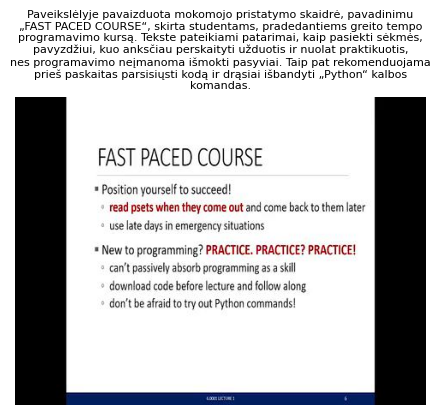

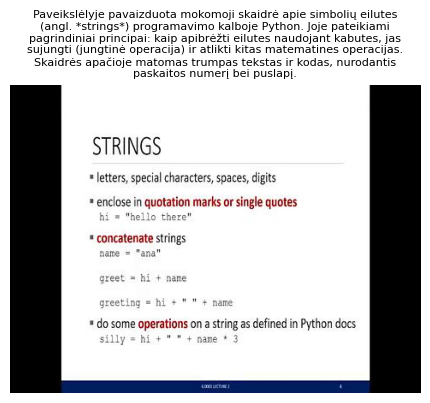

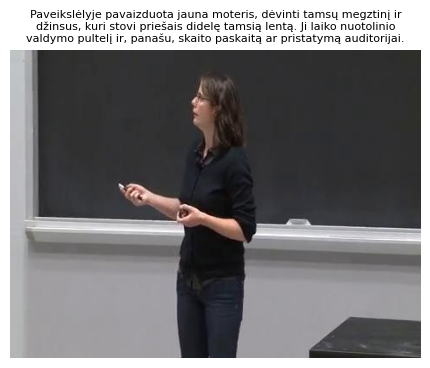

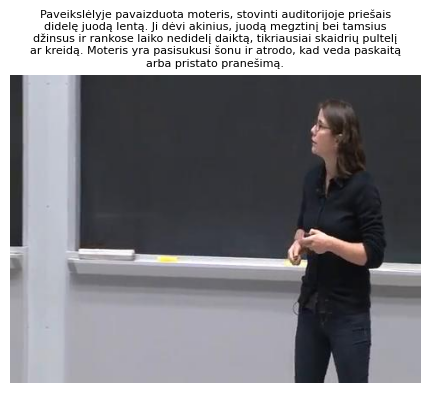

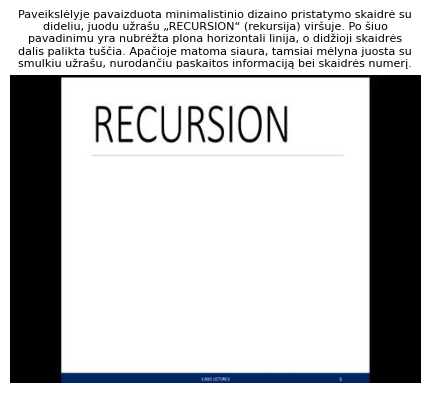

In [10]:
#@title 📊 STEP 3: Show Results
from PIL import Image
import matplotlib.pyplot as plt
import textwrap

for filename in sorted(os.listdir(desc_dir)):
    name = os.path.splitext(filename)[0]
    with open(os.path.join(desc_dir, filename), encoding="utf-8") as f:
        text = f.read()
    plt.figure(figsize=(6, 4))
    plt.imshow(Image.open(os.path.join(frame_dir, name + ".jpg")))
    plt.axis("off")
    plt.title("\n".join(textwrap.wrap(text, 70)), fontsize=8)
    plt.show()

## 💾 STEP 4: Išsaugojimas
Aprašymai supakuojami į `image-descriptions.zip` ir parsisiunčiami.

In [11]:
#@title 💾 STEP 4: Zip and Download
import shutil

shutil.make_archive("/content/image-descriptions", "zip", desc_dir)
files.download("/content/image-descriptions.zip")
print("✅ image-descriptions.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ image-descriptions.zip
